### Aidan Kaiser
#### Guitar Chord Classification
#### MSDS 561 - Machine Learning

In [1]:
import os
import pandas as pd

import librosa
import librosa.display
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import librosa.display

import torch
from torch.utils.data import DataLoader

from model import CustomCNN
from train import train_one_epoch, validate, test, run_experiment, get_predictions
from utils import get_dataloaders, plot_training, plot_confusion_matrix, get_feature_map_sizes, count_parameters, load_audio_dataset, wav_to_melspectrogram, pad_or_truncate
from guitar_chord_dataset import GuitarChordDataset


In [2]:
# load in all the chord .wav into dataframes
train_df = load_audio_dataset("./data/Train")
test_df = load_audio_dataset("./data/Test")

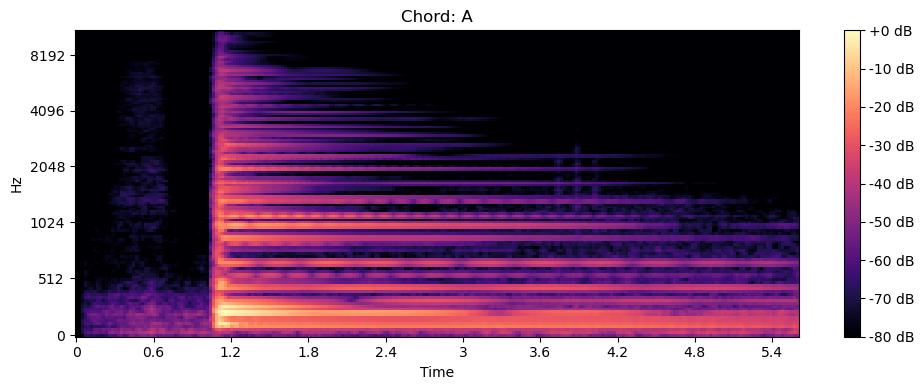

In [3]:
# convert each .wav into a spectrogram image, store in the dataframe
train_df["spectrogram"] = train_df["file_path"].apply(wav_to_melspectrogram)
test_df["spectrogram"] = test_df["file_path"].apply(wav_to_melspectrogram)

# grabs the first chord spectrogram and label
spec = train_df["spectrogram"][0]
label = train_df["label"][0]

# plots the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(spec, x_axis="time", y_axis="mel", sr=22050)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Chord: {label}")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train_df["label"])


# Split train into train/val
train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)

# Create datasets
train_dataset = GuitarChordDataset(train_split.reset_index(drop=True), le)
val_dataset   = GuitarChordDataset(val_split.reset_index(drop=True), le)
test_dataset  = GuitarChordDataset(test_df, le)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Set up model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN(
    num_layers=3,
    filters=[32, 64, 128],
    kernel_sizes=[3, 3, 3],
    use_pooling=True,
    dropout=0.3,
    num_classes=len(le.classes_)  # number of unique chords
).to(device)

# Train using your existing run_experiment from train.py
history = run_experiment(model, train_loader, val_loader, device, num_epochs=20, lr=0.001)

/opt/conda/envs/dl_course/lib/python3.9/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 805: MPS client failed to connect to the MPS control daemon or the MPS server (Triggered internally at /opt/conda/conda-bld/pytorch_1720538643151/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch [  1/20]  Train Loss: 3.23  Train Acc: 0.06  |  Val Loss: 3.20  Val Acc: 0.05
Epoch [  2/20]  Train Loss: 3.10  Train Acc: 0.09  |  Val Loss: 3.05  Val Acc: 0.09
Epoch [  3/20]  Train Loss: 2.84  Train Acc: 0.19  |  Val Loss: 2.65  Val Acc: 0.29
Epoch [  4/20]  Train Loss: 2.36  Train Acc: 0.38  |  Val Loss: 2.01  Val Acc: 0.48
Epoch [  5/20]  Train Loss: 1.31  Train Acc: 0.70  |  Val Loss: 0.81  Val Acc: 0.78
Epoch [  6/20]  Train Loss: 0.40  Train Acc: 0.92  |  Val Loss: 0.29  Val Acc: 0.91
Epoch [  7/20]  Train Loss: 0.09  Train Acc: 0.98  |  Val Loss: 0.10  Val Acc: 0.97
Epoch [  8/20]  Train Loss: 0.02  Train Acc: 1.00  |  Val Loss: 0.09  Val Acc: 0.97
Epoch [  9/20]  Train Loss: 0.01  Train Acc: 1.00  |  Val Loss: 0.06  Val Acc: 0.99
Epoch [ 10/20]  Train Loss: 0.01  Train Acc: 1.00  |  Val Loss: 0.07  Val Acc: 0.98
Epoch [ 11/20]  Train Loss: 0.00  Train Acc: 1.00  |  Val Loss: 0.08  Val Acc: 0.97
Epoch [ 12/20]  Train Loss: 0.00  Train Acc: 1.00  |  Val Loss: 0.06  Val Ac

Test Accuracy: 0.81


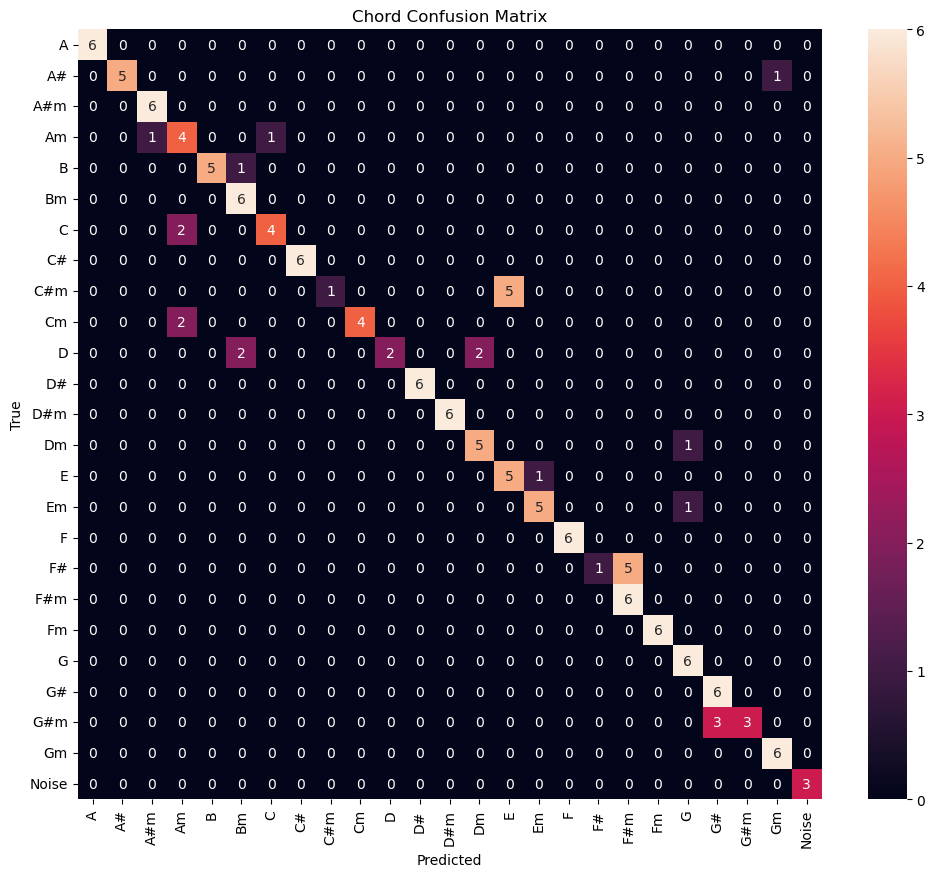

In [5]:
from train import test, get_predictions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Test accuracy
test_acc = test(model, test_loader, device)
print(f"Test Accuracy: {test_acc:.2f}")

# Confusion matrix
true_labels, pred_labels = get_predictions(model, test_loader, device)
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Chord Confusion Matrix")
plt.show()